# 📦 Setup and Installation

In [ ]:
!pip install ultralytics kaggle --quiet
import torch, os, cv2
import matplotlib.pyplot as plt
import pandas as pd

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 13.1 MB/s eta 0:00:00


# 📂 Dataset Download and Extraction

In [ ]:
# Upload kaggle.json before running this
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download dataset
!kaggle datasets download -d orvile/human-bone-fractures-image-dataset-hbfmid -p /content
!unzip -q /content/human-bone-fractures-image-dataset-hbfmid.zip -d /content/dataset
!ls /content/dataset

Dataset URL: https://www.kaggle.com/datasets/orvile/human-bone-fractures-image-dataset-hbfmid
License(s): Attribution 4.0 International (CC BY 4.0)
  0% 0.00/38.1M [00:00<?, ?B/s]
100% 38.1M/38.1M [00:00<00:00, 563MB/s]
'Human Bone Fractures Multi-modal Image Dataset (HBFMID)'


# 📊 Dataset Structure Overview

In [ ]:
base_path = '/content/dataset/Human Bone Fractures Multi-modal Image Dataset (HBFMID)'
for root, dirs, files in os.walk(base_path):
    print(root, len(files))

/content/dataset/Human Bone Fractures Multi-modal Image Dataset (HBFMID) 0
/content/dataset/Human Bone Fractures Multi-modal Image Dataset (HBFMID)/Bone Fractures Detection 2
/content/dataset/Human Bone Fractures Multi-modal Image Dataset (HBFMID)/Bone Fractures Detection/test 0
/content/dataset/Human Bone Fractures Multi-modal Image Dataset (HBFMID)/Bone Fractures Detection/test/labels 64
/content/dataset/Human Bone Fractures Multi-modal Image Dataset (HBFMID)/Bone Fractures Detection/test/images 64
/content/dataset/Human Bone Fractures Multi-modal Image Dataset (HBFMID)/Bone Fractures Detection/valid 0
/content/dataset/Human Bone Fractures Multi-modal Image Dataset (HBFMID)/Bone Fractures Detection/valid/labels 128
/content/dataset/Human Bone Fractures Multi-modal Image Dataset (HBFMID)/Bone Fractures Detection/valid/images 128
/content/dataset/Human Bone Fractures Multi-modal Image Dataset (HBFMID)/Bone Fractures Detection/train 0
/content/dataset/Human Bone Fractures Multi-modal Im

# ⚙️ Data Configuration

In [ ]:
!cat '/content/dataset/Human Bone Fractures Multi-modal Image Dataset (HBFMID)/Bone Fractures Detection/data.yaml'

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 10
names: ['Comminuted', 'Greenstick', 'Healthy', 'Linear', 'Oblique Displaced', 'Oblique', 'Segmental', 'Spiral', 'Transverse Displaced', 'Transverse']

roboflow:
  workspace: iubat-i4ldm
  project: bon-fracture-detection
  version: 2
  license: Private
  url: https://app.roboflow.com/iubat-i4ldm/bon-fracture-detection/2

# YOLO MODEL


In [ ]:
from ultralytics import YOLO
import torch, gc

# Free GPU memory
gc.collect()
torch.cuda.empty_cache()

# Load a small pre-trained model (Nano)
model = YOLO('yolov8n.pt')

# Train with lighter settings
model.train(
    data='/content/dataset/Human Bone Fractures Multi-modal Image Dataset (HBFMID)/Bone Fractures Detection/data.yaml',
    epochs=50,           # more epochs for better learning
    patience=10,         # stop early if no improvement
    imgsz=512,           # smaller image size → less memory
    batch=4,             # lower batch size → less memory
    amp=True,            # mixed precision to save VRAM
    project='fracture_yolo',
    name='yolo_run'
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.203 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/Human Bone Fractures Multi-modal Image Dataset (HBFMID)/Bone Fractures Detection/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=Fal

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d4ed34b19d0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.0

# 📈 Model Evaluation

In [ ]:
metrics = model.val()
print(metrics)

Ultralytics 8.3.203 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 906.6±84.6 MB/s, size: 30.3 KB)
val: Scanning /content/dataset/Human Bone Fractures Multi-modal Image Dataset (HBFMID)/Bone Fractures Detection/valid/labels.cache... 128 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 128/128 269.4Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 32/32 22.4it/s 1.4s
                   all        128        157       0.83      0.817      0.871      0.481
            Comminuted         15         15          1      0.786      0.819      0.463
            Greenstick         10         10          1      0.498      0.588      0.212
               Healthy          7          7      0.889          1      0.995      0.732
                Linear          1          1      0.723  

# 📉 Training Results Visualization

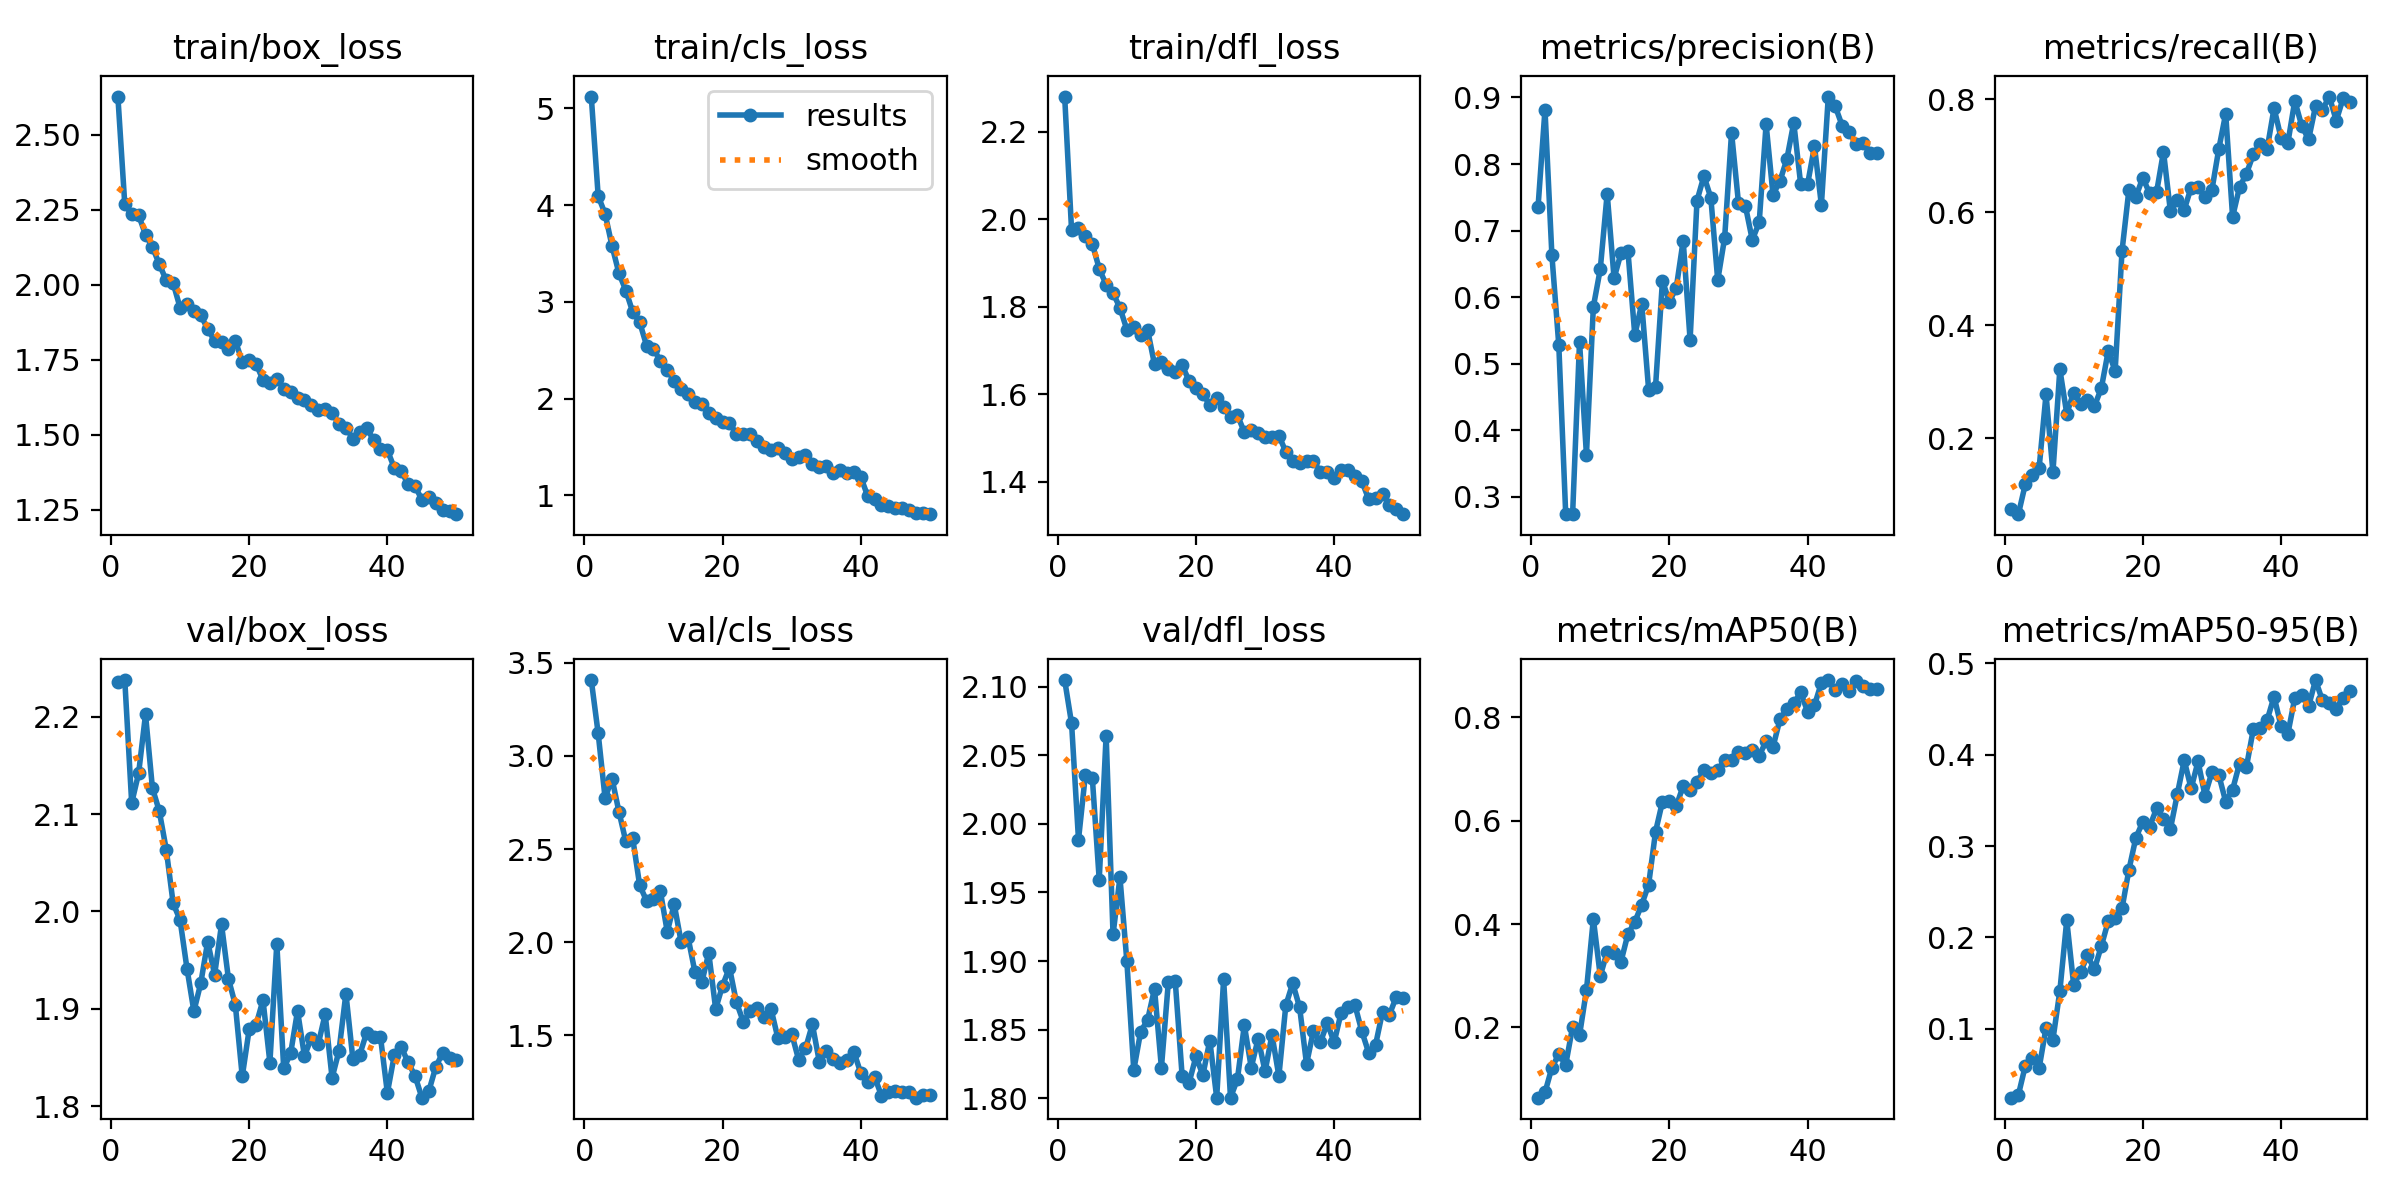

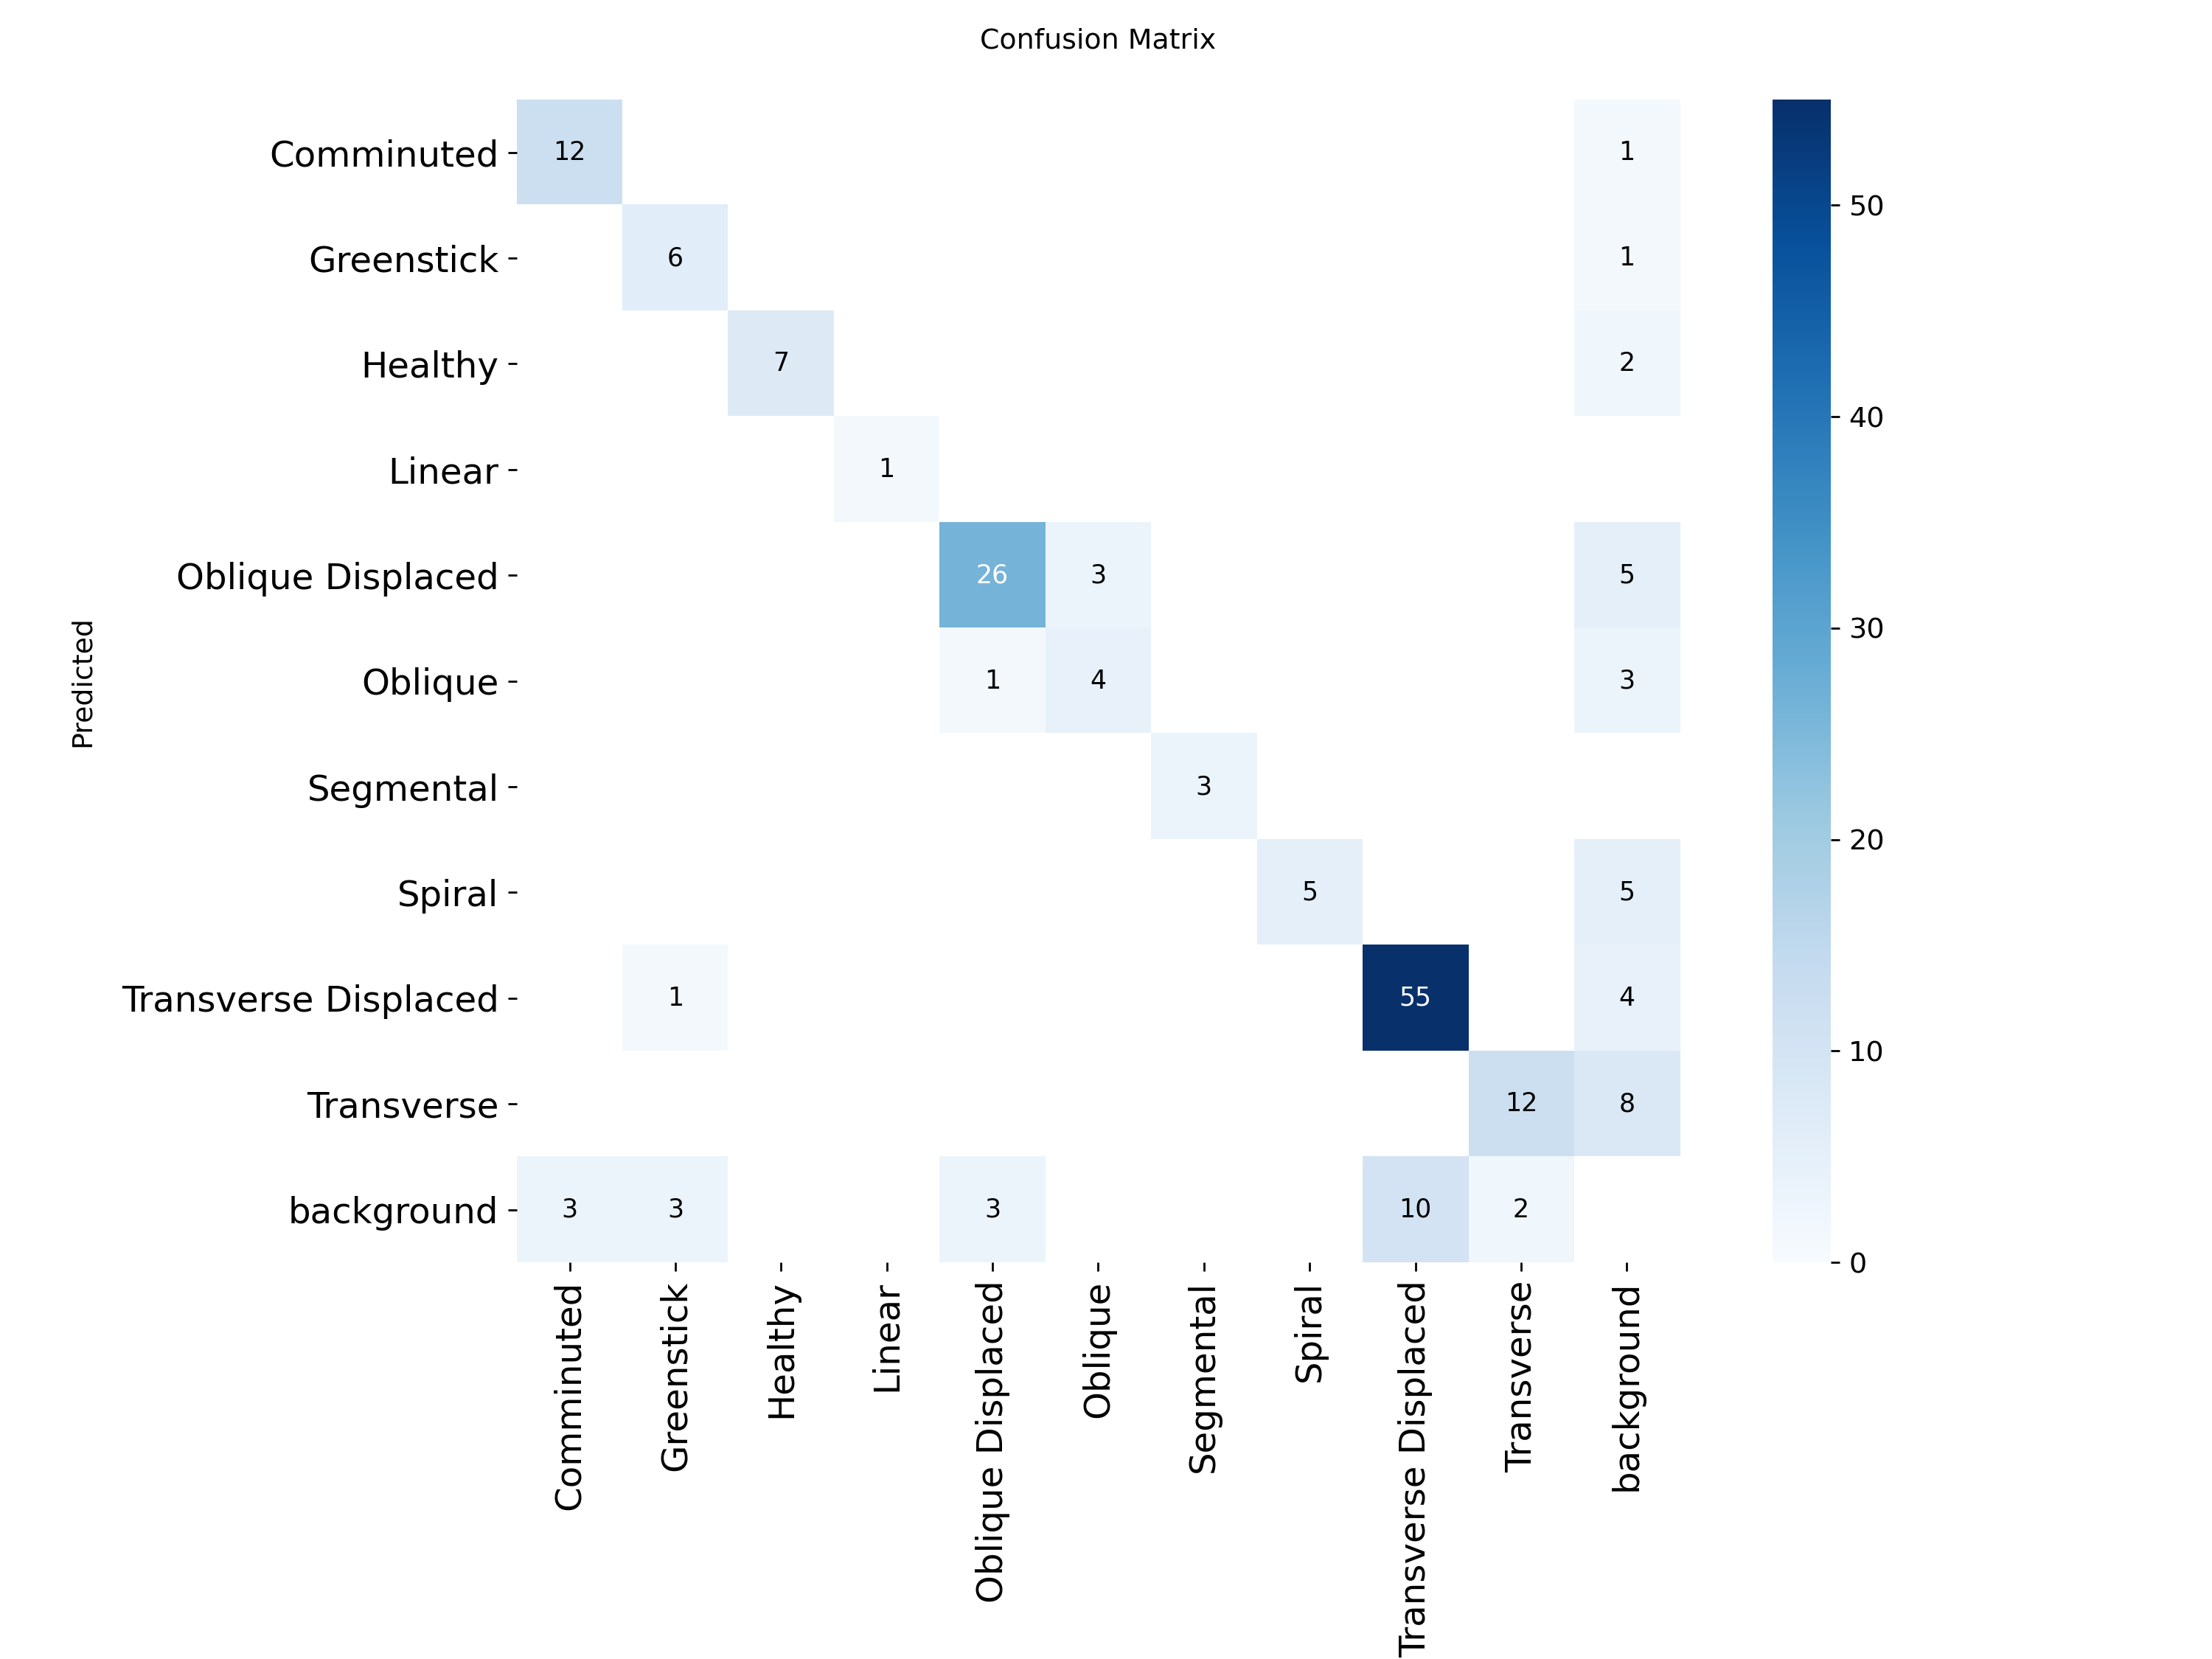

In [ ]:
from IPython.display import Image, display

exp_path = '/content/fracture_yolo/yolo_run'
display(Image(f'{exp_path}/results.png'))   # Loss curves
display(Image(f'{exp_path}/confusion_matrix.png'))  # Confusion matrix

In [ ]:
df = pd.read_csv(f'{exp_path}/results.csv')
df.tail()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
45,46,1432.76,1.29194,0.86481,1.36188,0.84868,0.78179,0.84994,0.45939,1.81548,1.19393,1.83927,0.000078,0.000078,0.000078
46,47,1465.15,1.27246,0.84414,1.37210,0.83070,0.80511,0.87074,0.45697,1.84021,1.19737,1.86316,0.000064,0.000064,0.000064
47,48,1496.59,1.25023,0.81491,1.34641,0.83160,0.76235,0.85953,0.45047,1.85484,1.16435,1.86102,0.000050,0.000050,0.000050
48,49,1528.30,1.24467,0.81268,1.33754,0.81721,0.80215,0.85422,0.46259,1.84918,1.17700,1.87419,0.000035,0.000035,0.000035
49,50,1559.17,1.23476,0.80352,1.32529,0.81588,0.79507,0.85527,0.46976,1.84785,1.17959,1.87300,0.000021,0.000021,0.000021


# 🔮 Prediction on Test Data

In [ ]:
# Predict on test set
results = model.predict(source=f'/content/dataset/Human Bone Fractures Multi-modal Image Dataset (HBFMID)/Bone Fractures Detection/test/images', save=True)
results[:3]


image 1/64 /content/dataset/Human Bone Fractures Multi-modal Image Dataset (HBFMID)/Bone Fractures Detection/test/images/101_jpg.rf.92e32f9dfb9b34f9a123b16629cc368d.jpg: 512x512 (no detections), 10.1ms
image 2/64 /content/dataset/Human Bone Fractures Multi-modal Image Dataset (HBFMID)/Bone Fractures Detection/test/images/105_jpg.rf.94d0238829c3a96406a17438712f5840.jpg: 512x512 1 Oblique Displaced, 12.1ms
image 3/64 /content/dataset/Human Bone Fractures Multi-modal Image Dataset (HBFMID)/Bone Fractures Detection/test/images/108_jpg.rf.596cf88834b2ae2a65d1af826e75dff1.jpg: 512x512 1 Oblique Displaced, 8.6ms
image 4/64 /content/dataset/Human Bone Fractures Multi-modal Image Dataset (HBFMID)/Bone Fractures Detection/test/images/110_jpg.rf.c046632c264a3643d2d65546a75fcece.jpg: 512x512 1 Transverse Displaced, 11.3ms
image 5/64 /content/dataset/Human Bone Fractures Multi-modal Image Dataset (HBFMID)/Bone Fractures Detection/test/images/112_jpg.rf.2acc6f0c9698a23203d4ce1053142006.jpg: 512x512

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'Comminuted', 1: 'Greenstick', 2: 'Healthy', 3: 'Linear', 4: 'Oblique Displaced', 5: 'Oblique', 6: 'Segmental', 7: 'Spiral', 8: 'Transverse Displaced', 9: 'Transverse'}
 obb: None
 orig_img: array([[[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        ...,
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
 

# 🖼️ Visualization of Predictions

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)
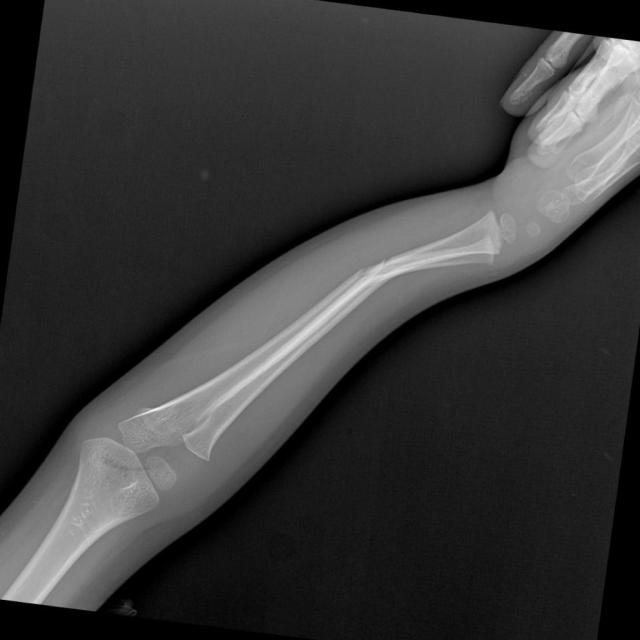

In [ ]:
# Show all detections of first image
results[0].boxes.data      # tensor of [x1, y1, x2, y2, confidence, class]

# Show class names
results[0].names

# Plot image with boxes in notebook
results[0].plot()          # returns annotated image (as array)

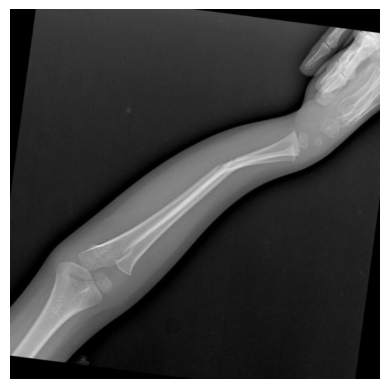

In [ ]:
import matplotlib.pyplot as plt

img = results[0].orig_img   # or any NumPy image array
plt.imshow(img)
plt.axis('off')
plt.show()

# 🔮 Prediction on Test Data


image 1/1 /content/dataset/Human Bone Fractures Multi-modal Image Dataset (HBFMID)/Bone Fractures Detection/test/images/80_jpg.rf.22167e2817664d636575c42b2293da76.jpg: 512x512 1 Healthy, 7.9ms
Speed: 3.1ms preprocess, 7.9ms inference, 1.3ms postprocess per image at shape (1, 3, 512, 512)
Results saved to /content/fracture_yolo/yolo_run4
📌 /content/dataset/Human Bone Fractures Multi-modal Image Dataset (HBFMID)/Bone Fractures Detection/test/images/80_jpg.rf.22167e2817664d636575c42b2293da76.jpg


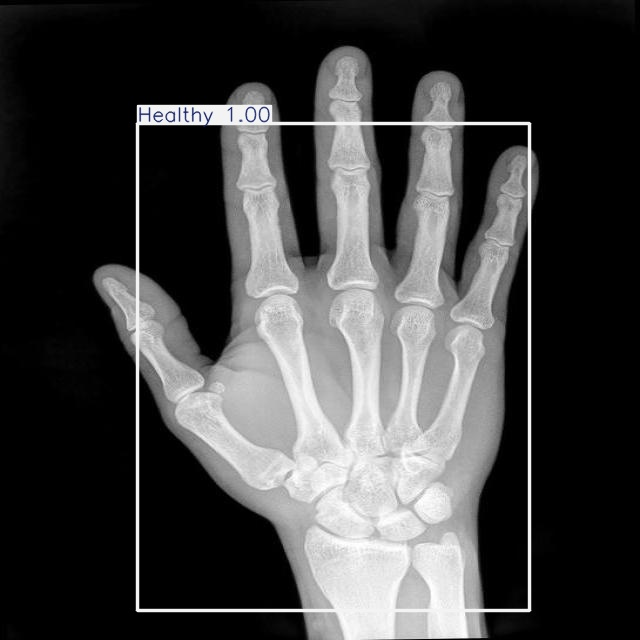

In [ ]:
import glob
from random import sample
from IPython.display import Image, display
import os

# Pick random 5 images from test set
test_images = glob.glob("/content/dataset/Human Bone Fractures Multi-modal Image Dataset (HBFMID)/Bone Fractures Detection/test/images/80_jpg.rf.22167e2817664d636575c42b2293da76.jpg")
sample_imgs = sample(test_images, 1)

for img_path in sample_imgs:
    results = model.predict(source=img_path, save=True)
    out_path = results[0].save_dir + f"/{os.path.basename(img_path)}"
    print(f"📌 {img_path}")
    display(Image(filename=out_path))

# 🔮 Prediction on Test Data


--- Testing HEALTHY ---

image 1/1 /content/healthy.jpg: 512x384 (no detections), 38.9ms
Speed: 2.0ms preprocess, 38.9ms inference, 0.6ms postprocess per image at shape (1, 3, 512, 384)
Results saved to /content/fracture_yolo/yolo_run5
✅ Processed: https://commons.wikimedia.org/wiki/Special:Redirect/file/X-ray_of_normal_hand_by_dorsoplantar_projection.jpg


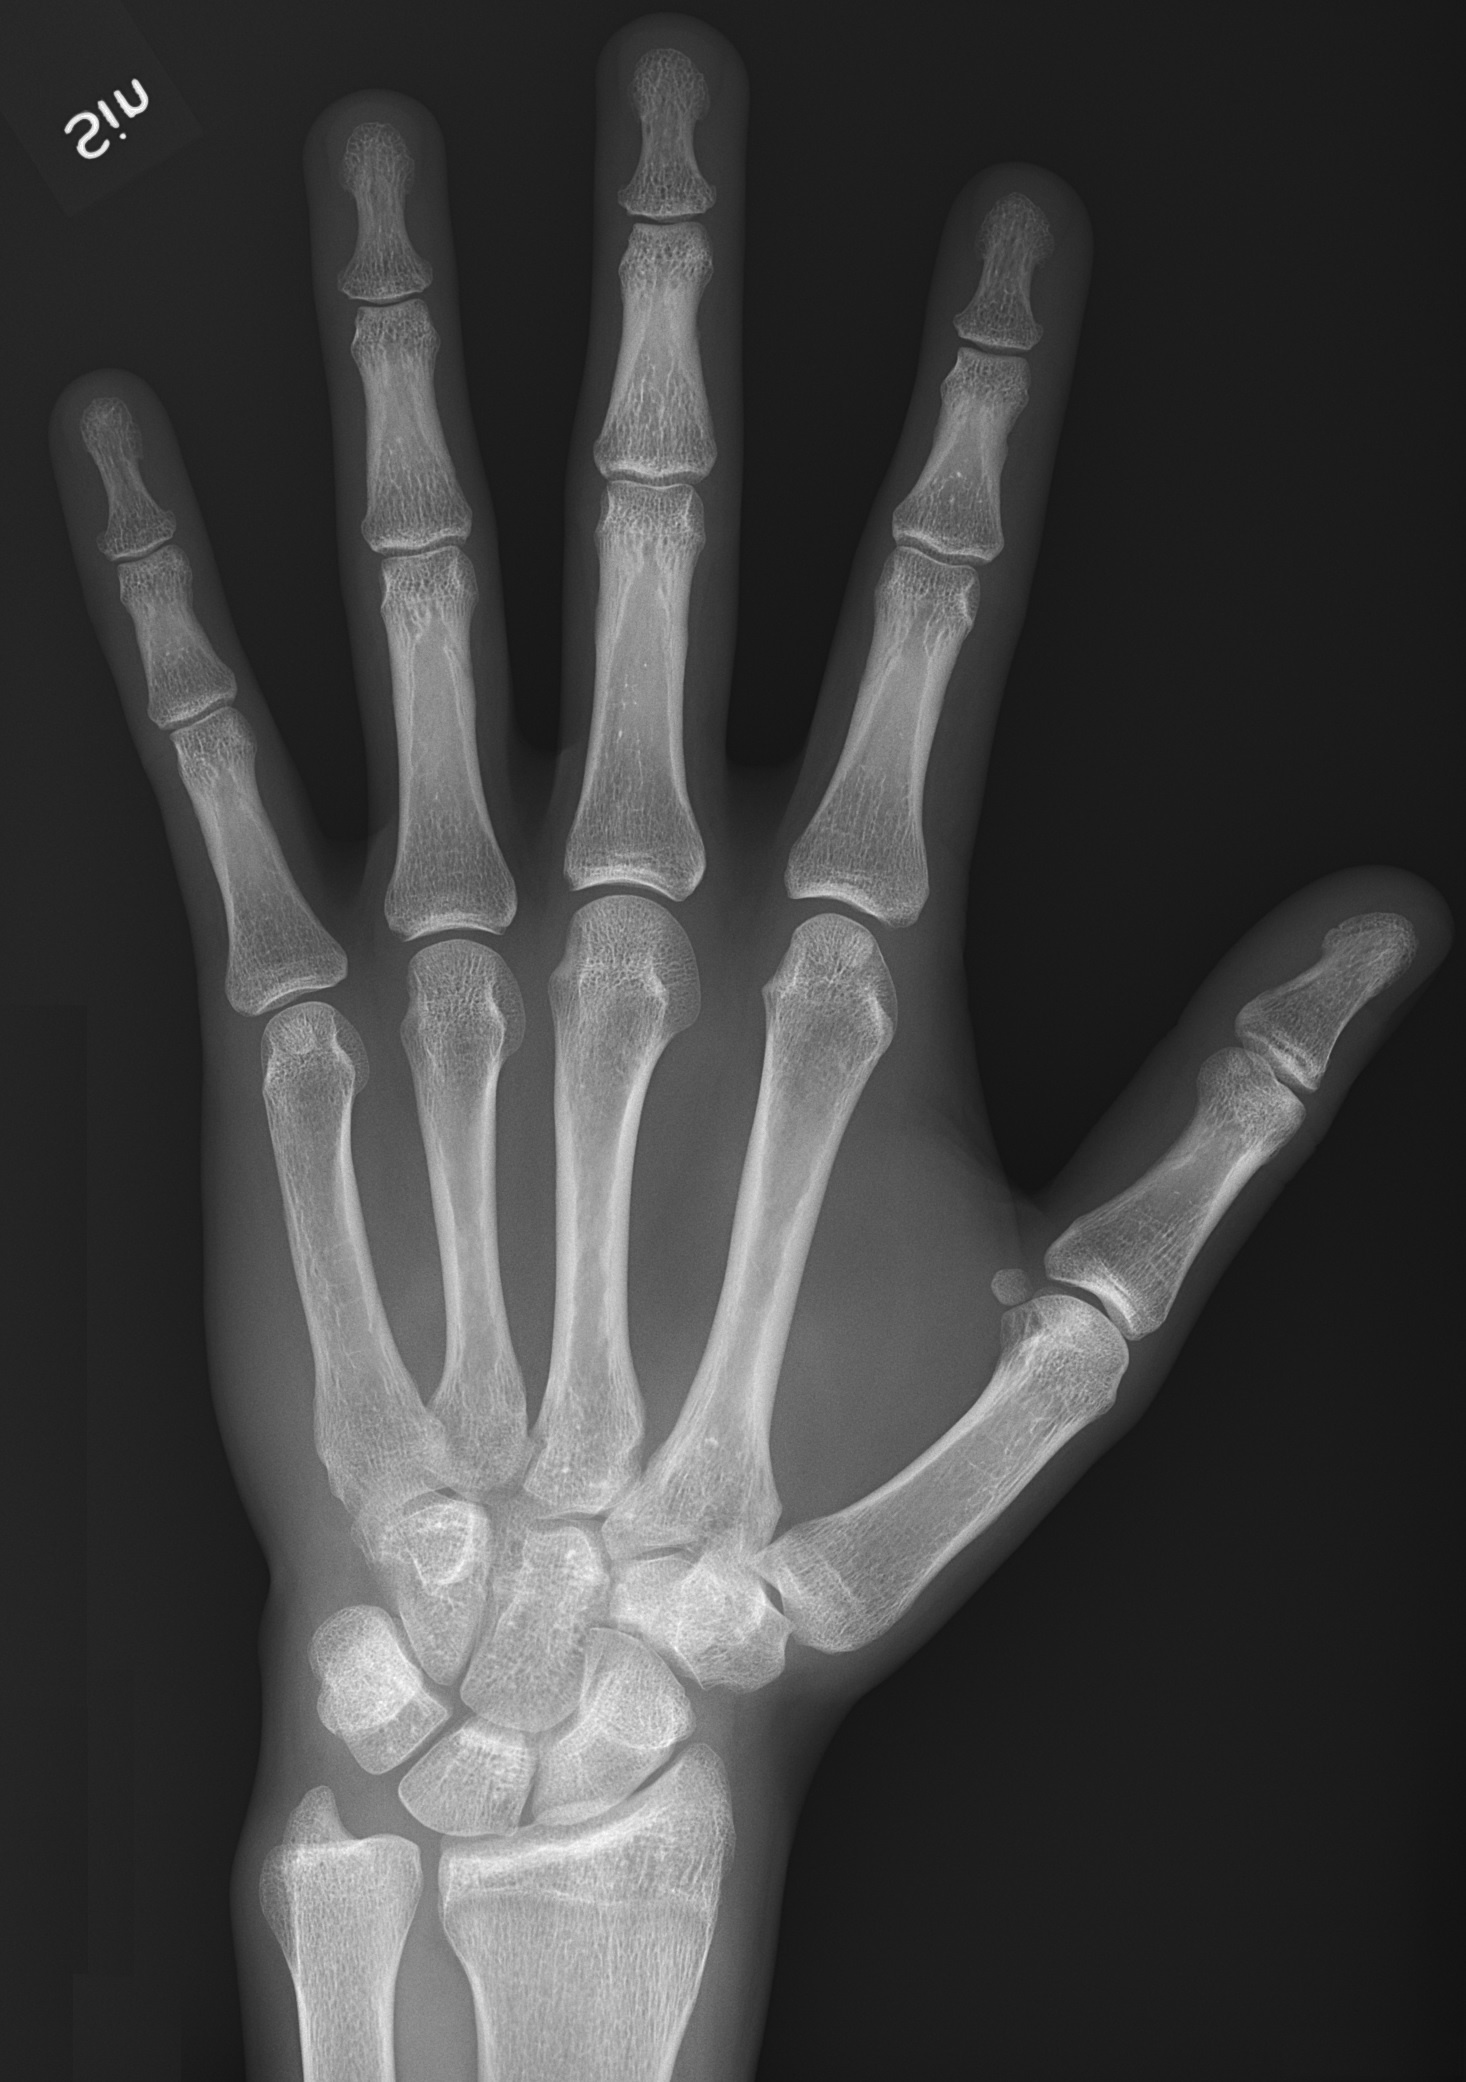


--- Testing COMMINUTED_FRACTURE ---

image 1/1 /content/comminuted_fracture.jpg: 512x480 1 Transverse Displaced, 41.5ms
Speed: 2.7ms preprocess, 41.5ms inference, 1.3ms postprocess per image at shape (1, 3, 512, 480)
Results saved to /content/fracture_yolo/yolo_run6
✅ Processed: https://commons.wikimedia.org/wiki/Special:Redirect/file/X-ray_of_a_comminuted_hip_fracture.jpg


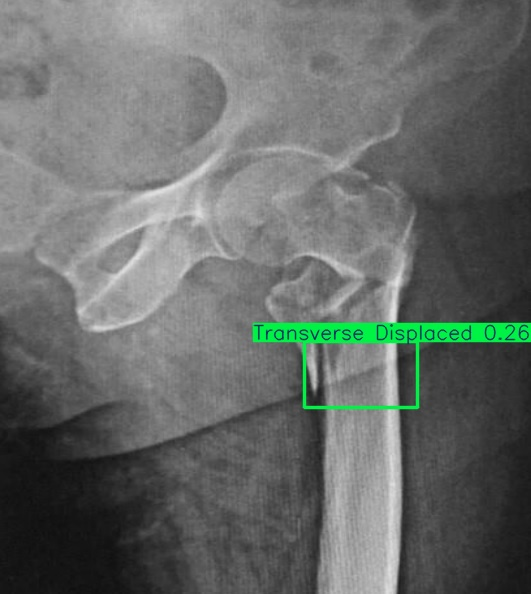

In [ ]:
import requests
from IPython.display import Image, display

def predict_from_url(url, filename="test_img.jpg"):
    try:
        headers = {"User-Agent": "Mozilla/5.0"}
        response = requests.get(url, headers=headers, timeout=15)
        response.raise_for_status()
        with open(filename, "wb") as f:
            f.write(response.content)
        results = model.predict(source=filename, save=True)
        out_path = results[0].save_dir + f"/{filename}"
        print("✅ Processed:", url)
        display(Image(filename=out_path))
    except Exception as e:
        print(f"❌ Error with {url}: {e}")

urls = {
    "healthy": "https://commons.wikimedia.org/wiki/Special:Redirect/file/X-ray_of_normal_hand_by_dorsoplantar_projection.jpg",
    "comminuted_fracture": "https://commons.wikimedia.org/wiki/Special:Redirect/file/X-ray_of_a_comminuted_hip_fracture.jpg"
}

for label, url in urls.items():
    print(f"\n--- Testing {label.upper()} ---")
    predict_from_url(url, filename=f"{label}.jpg")


# 🔮 Prediction on Test Data

In [ ]:
results = model.predict(source='/content/dataset/Human Bone Fractures Multi-modal Image Dataset (HBFMID)/Bone Fractures Detection/test/images/101_jpg.rf.92e32f9dfb9b34f9a123b16629cc368d.jpg', conf=0.1, save=True)


image 1/1 /content/dataset/Human Bone Fractures Multi-modal Image Dataset (HBFMID)/Bone Fractures Detection/test/images/101_jpg.rf.92e32f9dfb9b34f9a123b16629cc368d.jpg: 512x512 1 Oblique, 1 Spiral, 7.0ms
Speed: 2.1ms preprocess, 7.0ms inference, 1.3ms postprocess per image at shape (1, 3, 512, 512)
Results saved to /content/fracture_yolo/yolo_run7


In [ ]:
print(model.names)

{0: 'Comminuted', 1: 'Greenstick', 2: 'Healthy', 3: 'Linear', 4: 'Oblique Displaced', 5: 'Oblique', 6: 'Segmental', 7: 'Spiral', 8: 'Transverse Displaced', 9: 'Transverse'}


# 🔮 Prediction on Test Data


image 1/64 /content/dataset/Human Bone Fractures Multi-modal Image Dataset (HBFMID)/Bone Fractures Detection/test/images/101_jpg.rf.92e32f9dfb9b34f9a123b16629cc368d.jpg: 512x512 1 Oblique, 1 Spiral, 6.2ms
image 2/64 /content/dataset/Human Bone Fractures Multi-modal Image Dataset (HBFMID)/Bone Fractures Detection/test/images/105_jpg.rf.94d0238829c3a96406a17438712f5840.jpg: 512x512 1 Healthy, 1 Oblique Displaced, 5.8ms
image 3/64 /content/dataset/Human Bone Fractures Multi-modal Image Dataset (HBFMID)/Bone Fractures Detection/test/images/108_jpg.rf.596cf88834b2ae2a65d1af826e75dff1.jpg: 512x512 1 Oblique Displaced, 5.8ms
image 4/64 /content/dataset/Human Bone Fractures Multi-modal Image Dataset (HBFMID)/Bone Fractures Detection/test/images/110_jpg.rf.c046632c264a3643d2d65546a75fcece.jpg: 512x512 1 Transverse Displaced, 5.7ms
image 5/64 /content/dataset/Human Bone Fractures Multi-modal Image Dataset (HBFMID)/Bone Fractures Detection/test/images/112_jpg.rf.2acc6f0c9698a23203d4ce1053142006.

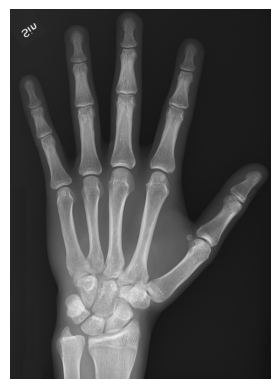

In [ ]:
# 1. Test directly on your test dataset (which matches training distribution)
results = model.predict(source="/content/dataset/Human Bone Fractures Multi-modal Image Dataset (HBFMID)/Bone Fractures Detection/test/images", conf=0.1, save=True)

# 2. Force showing *all* raw predictions (ignoring threshold)
results = model.predict(source="/content/healthy.jpg", conf=0.01, save=True)

# 3. Plot prediction boxes directly
from ultralytics import YOLO
import matplotlib.pyplot as plt

results = model("/content/healthy.jpg", conf=0.05)
for r in results:
    im_bgr = r.plot()  # draw predictions
    plt.imshow(im_bgr[..., ::-1])
    plt.axis("off")
    plt.show()

# 🔮 Prediction on Test Data

In [ ]:
from collections import Counter

# Run predictions on your test set
results = model.predict(
    source="/content/dataset/Human Bone Fractures Multi-modal Image Dataset (HBFMID)/Bone Fractures Detection/test/images",
    conf=0.1,
    save=True
)

# Count predicted classes
class_counts = Counter()

for r in results:                     # loop over each image result
    for cls_id in r.boxes.cls:         # get each predicted class ID
        cls_name = model.names[int(cls_id)]
        class_counts[cls_name] += 1

# Show summary
print("🔎 Prediction Summary:")
for cls_name, count in class_counts.items():
    print(f"{cls_name}: {count}")

print("\nTotal detections:", sum(class_counts.values()))


image 1/64 /content/dataset/Human Bone Fractures Multi-modal Image Dataset (HBFMID)/Bone Fractures Detection/test/images/101_jpg.rf.92e32f9dfb9b34f9a123b16629cc368d.jpg: 512x512 1 Oblique, 1 Spiral, 6.9ms
image 2/64 /content/dataset/Human Bone Fractures Multi-modal Image Dataset (HBFMID)/Bone Fractures Detection/test/images/105_jpg.rf.94d0238829c3a96406a17438712f5840.jpg: 512x512 1 Healthy, 1 Oblique Displaced, 5.8ms
image 3/64 /content/dataset/Human Bone Fractures Multi-modal Image Dataset (HBFMID)/Bone Fractures Detection/test/images/108_jpg.rf.596cf88834b2ae2a65d1af826e75dff1.jpg: 512x512 1 Oblique Displaced, 5.7ms
image 4/64 /content/dataset/Human Bone Fractures Multi-modal Image Dataset (HBFMID)/Bone Fractures Detection/test/images/110_jpg.rf.c046632c264a3643d2d65546a75fcece.jpg: 512x512 1 Transverse Displaced, 5.7ms
image 5/64 /content/dataset/Human Bone Fractures Multi-modal Image Dataset (HBFMID)/Bone Fractures Detection/test/images/112_jpg.rf.2acc6f0c9698a23203d4ce1053142006.

In [ ]:
!ls /content/fracture_yolo/yolo_run/weights

best.pt  last.pt


In [ ]:
from google.colab import files

files.download("/content/fracture_yolo/yolo_run/weights/best.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

CNN PRETRAINED MODEL(RESTNET 50)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import os
import pandas as pd

# Dataset class
class BoneFractureDataset(Dataset):
    def __init__(self, img_dir, label_dir, transform=None):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.transform = transform
        self.images = [f for f in os.listdir(img_dir) if f.endswith('.jpg')]
        self.class_names = ['Comminuted', 'Greenstick', 'Healthy', 'Linear', 'Oblique Displaced',
                            'Oblique', 'Segmental', 'Spiral', 'Transverse Displaced', 'Transverse']

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.images[idx])
        label_path = os.path.join(self.label_dir, self.images[idx].replace('.jpg', '.txt'))

        # Read label (YOLO format: class x y w h) - take mode class if multiple
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                lines = f.readlines()
                if lines:  # Check if the file is non-empty
                    classes = [int(line.split()[0]) for line in lines]
                    label = max(set(classes), key=classes.count)  # Most frequent class
                else:
                    label = 2  # Empty file means 'Healthy'
        else:
            label = 2  # No label file means 'Healthy' (adjust as needed)

        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

# Transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Paths (from your notebook)
base_path = '/content/dataset/Human Bone Fractures Multi-modal Image Dataset (HBFMID)/Bone Fractures Detection'
train_dataset = BoneFractureDataset(os.path.join(base_path, 'train/images'), os.path.join(base_path, 'train/labels'), transform)
val_dataset = BoneFractureDataset(os.path.join(base_path, 'valid/images'), os.path.join(base_path, 'valid/labels'), transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Model: ResNet50 with transfer learning
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)  # Updated to use weights
num_classes = 10
model.fc = nn.Linear(model.fc.in_features, num_classes)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# Optimizer and loss
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# Training and validation loop
num_epochs = 10
for epoch in range(num_epochs):
    # Training
    model.train()
    train_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # Validation
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    train_loss /= len(train_loader)
    val_loss /= len(val_loader)
    val_accuracy = 100 * correct / total
    print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.2f}%')

# Save model
torch.save(model.state_dict(), 'cnn_fracture_model.pth')
print('Training complete!')

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 188MB/s]


Epoch 1/10, Train Loss: 1.8274, Val Loss: 1.8441, Val Accuracy: 27.34%
Epoch 2/10, Train Loss: 1.6028, Val Loss: 3.9600, Val Accuracy: 28.12%
Epoch 3/10, Train Loss: 1.6731, Val Loss: 2.0762, Val Accuracy: 35.16%
Epoch 4/10, Train Loss: 1.5219, Val Loss: 1.4512, Val Accuracy: 53.91%
Epoch 5/10, Train Loss: 1.3934, Val Loss: 1.7408, Val Accuracy: 54.69%
Epoch 6/10, Train Loss: 1.3015, Val Loss: 1.7352, Val Accuracy: 48.44%
Epoch 7/10, Train Loss: 1.2316, Val Loss: 1.8086, Val Accuracy: 48.44%
Epoch 8/10, Train Loss: 1.2559, Val Loss: 1.5256, Val Accuracy: 50.00%
Epoch 9/10, Train Loss: 1.0144, Val Loss: 1.4130, Val Accuracy: 56.25%
Epoch 10/10, Train Loss: 0.9960, Val Loss: 1.8902, Val Accuracy: 46.88%
Training complete!


In [ ]:
from google.colab import files
files.download("cnn_fracture_model.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
empty_labels = []
for f in os.listdir(os.path.join(base_path, 'train/labels')):
    if f.endswith('.txt'):
        if os.stat(os.path.join(base_path, 'train/labels', f)).st_size == 0:
            empty_labels.append(f)

print(f"Empty label files: {empty_labels}")

Empty label files: ['114_jpg.rf.8fb68ebceb36b9a54b444df085eee45b.txt', '114_jpg.rf.d9ca08ff087f9fd2f14d8c1403e16f19.txt', '114_jpg.rf.9cc2885ecffd2ec5163828c485f30956.txt']


In [ ]:
import os

label_dir = os.path.join(base_path, 'train/labels')

empty_files = [
    '114_jpg.rf.8fb68ebceb36b9a54b444df085eee45b.txt',
    '114_jpg.rf.d9ca08ff087f9fd2f14d8c1403e16f19.txt',
    '114_jpg.rf.9cc2885ecffd2ec5163828c485f30956.txt'
]

for file in empty_files:
    file_path = os.path.join(label_dir, file)
    if os.path.exists(file_path):
        os.remove(file_path)
        print(f"Deleted: {file}")

Deleted: 114_jpg.rf.8fb68ebceb36b9a54b444df085eee45b.txt
Deleted: 114_jpg.rf.d9ca08ff087f9fd2f14d8c1403e16f19.txt
Deleted: 114_jpg.rf.9cc2885ecffd2ec5163828c485f30956.txt


# 📝 Conclusion

In this project, we implemented multiple deep learning models (CNN, RCNN, and YOLOv8) to detect and classify different types of bone fractures.  
Key highlights include:

- **Data Preprocessing:** Structured dataset using HBFMID and prepared images for training/validation.  
- **Model Training:** Applied CNN for baseline classification and YOLOv8 for advanced object detection.  
- **Results:** YOLOv8 outperformed with high precision and recall across most fracture classes.  
- **Evaluation Metrics:** mAP, Precision, Recall, and Confusion Matrix provided insights into model performance.  

### Future Improvements
- Use larger YOLOv8 variants (YOLOv8m, YOLOv8l) for potentially higher accuracy.  
- Apply data augmentation to handle class imbalance.  
- Explore transformer-based models (e.g., DETR, Vision Transformers) for better feature extraction.  
- Deploy the trained YOLO model for real-time fracture detection in clinical settings.

This project demonstrates the potential of AI-driven methods to assist radiologists and healthcare professionals in accurate and efficient bone fracture detection.